In [24]:
import numpy as np
import scipy.stats 
import pylab as plt
import astropy.visualization.hist
from sklearn.neighbors import KernelDensity


For a BH of mass $M$ spin $ \chi\in [0,1] $, the irreducible mass is 
$$
M_{\rm irr} = M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}
$$
For convenience, let us define 

$$f(\chi) = \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}$$

Suppose you have repeated measurments of $M$ and $\chi$. This is just because we're still frequentists for now. When we will put our Bayesian hat on, these distributions will be the *posterior samples* from a single measurement.

Let's assume that

- the spin $\chi$ is uniformly distributed between 0 and 1.
- the mass $M$ is normally distributed with mean $\mu$ and standard deviation $\sigma$.
- (masses and spins are uncorrelated)

These are simplistic assumption that, however, are not too far from what we are now measuring with gravitational-wave detectors. It's a toy model, but not a totally unreasonable one.

**Tasks**:

1. Start with a value of $\sigma=0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a dimension of mass by $\mu$. Just set $\mu=1$ in your code and remember that all masses in the problem are measured in units of $\mu$. 

In [25]:
N = 10000 # Number of samples

# M  samples
mu = 1
sigma = 0.02
m = scipy.stats.norm(loc = mu, scale= sigma)
x = (m.rvs(N))

# Ki samples
ki = scipy.stats.uniform(loc = 0, scale= 1)
y = (ki.rvs(N))


def f(i):
    return np.sqrt((1+np.sqrt(1-i**2))/2)

# The product of both for M_irr:
M_irr = x*f(y)

In [26]:
# Check ki plot:
# plt.plot(y,f(y));

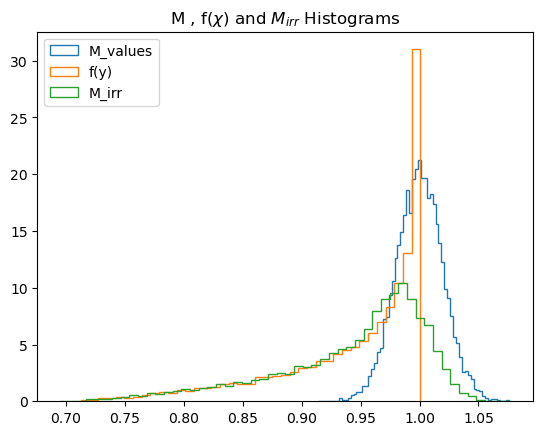

In [27]:
astropy.visualization.hist(x, bins= 'freedman', histtype='step', label='M_values',density = True)
astropy.visualization.hist(f(y), bins= 'freedman', histtype='step', label='f(y)',density = True)
astropy.visualization.hist(M_irr,bins='freedman', histtype='step', label='M_irr',density = True)
plt.title('M , f($\chi$) and $M_{irr}$ Histograms')
plt.legend();

2. Plot the resulting pdf of $M_{\rm irr}$. First try an histogram with one the rules of thumb we've seen above.

*Hint (for point 2)*: You don't know the functional form of the pdf of $M_{\rm irr}$... but you don't need it if you just want to generate samples! That's the nice thing about numerics!

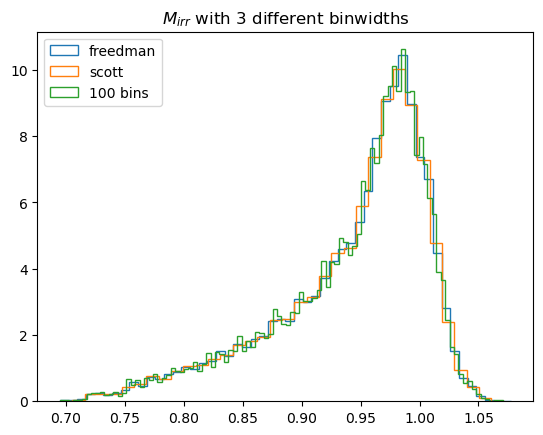

In [28]:
astropy.visualization.hist(M_irr,bins="freedman",density=True,histtype='step', label= 'freedman')
astropy.visualization.hist(M_irr,bins="scott",density=True,histtype='step', label= 'scott')
plt.hist(M_irr,bins=100,density=True,histtype='step', label= '100 bins')
plt.title('$M_{irr}$ with 3 different binwidths')
plt.legend();

3. Using the same samples, plot the distribution of $M_{\rm irr}$ using a KDE.

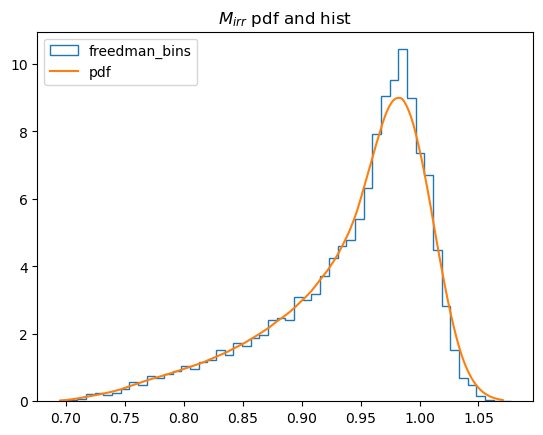

In [29]:
xgrid = np.linspace(M_irr.min(), M_irr.max(), N)

def kde_sklearn(data, bandwidth = 0.03, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

pdf_M_irr = kde_sklearn(M_irr)

astropy.visualization.hist(M_irr,bins="freedman",density=True,histtype='step', label= 'freedman_bins')
plt.plot(xgrid,pdf_M_irr, label= 'pdf')
plt.title('$M_{irr}$ pdf and hist')
plt.legend();


4. Compute the KS distance between ${M_{\rm irr}}/\mu$ and ${f}$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$. 
5. Compute the KS distance between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

*Hint (for points 4 and 5)*. This is a KS test between two sets for samples, `scipy.stats.ks_2samp`.

You should find that (i) $M_{\rm irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and (ii) $M_{\rm irr}$ is distributed like $M$ if  $\sigma\gg \mu$.

KstestResult(statistic=np.float64(0.0028), pvalue=np.float64(0.9999999999997335), statistic_location=np.float64(0.9999999989884079), statistic_sign=np.int8(-1)) KstestResult(statistic=np.float64(0.9866), pvalue=np.float64(0.0), statistic_location=np.float64(0.9999673136871622), statistic_sign=np.int8(1))
KstestResult(statistic=np.float64(0.0035), pvalue=np.float64(0.9999999820103361), statistic_location=np.float64(0.9999999989884079), statistic_sign=np.int8(-1)) KstestResult(statistic=np.float64(0.9851), pvalue=np.float64(0.0), statistic_location=np.float64(0.9999612225117298), statistic_sign=np.int8(1))
KstestResult(statistic=np.float64(0.0035), pvalue=np.float64(0.9999999820103361), statistic_location=np.float64(0.9999999989884079), statistic_sign=np.int8(-1)) KstestResult(statistic=np.float64(0.9822), pvalue=np.float64(0.0), statistic_location=np.float64(0.9999521853143937), statistic_sign=np.int8(1))
KstestResult(statistic=np.float64(0.0043), pvalue=np.float64(0.999986835553315), s

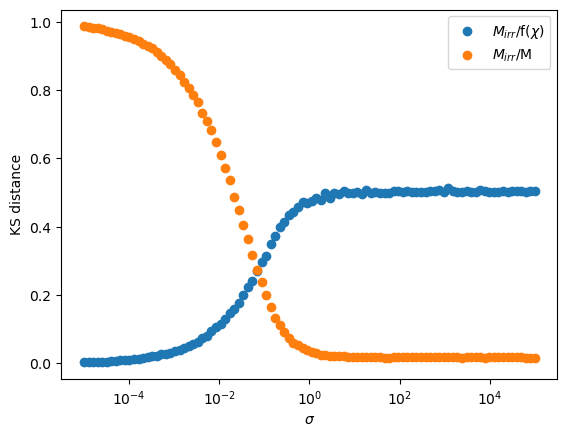

In [ ]:
sig_list = np.logspace(-5, 5, 100)

M_irr_list = []
x_list = []
ks_dist_f = []
ks_dist_m = []

for s in sig_list:

 m = scipy.stats.norm(loc = mu, scale= s)
 x = m.rvs(N)
 
 x_list.append(x)
 M_irr_list.append(x*f(y)) 
 ks_dist_f.append(scipy.stats.ks_2samp(x*f(y),f(y)))
 ks_dist_m.append(scipy.stats.ks_2samp(x*f(y),x))

plt.scatter(sig_list,ks_dist_f.statistic,label= '$M_{irr}$/f($\chi$)')
plt.scatter(sig_list,ks_dist_m.statistic,label= '$M_{irr}$/M')
plt.xscale('log')
plt.xlabel("$\sigma$")
plt.ylabel('KS distance')
plt.legend();

---

### Gaussian distribution -> Check the change in sigma when it goes to zero or for a very high value:
$$p(x|\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(\frac{-(x-\mu)^2}{2\sigma^2}\right)$$

* **NOTE:** M won't change much at low or high $\sigma$ values

1. If $\sigma$ goes to 0, `x` values range becomes narrow and concentrated around $\mu = 1$, then $M = 1$ and 
$$
M_{irr} = f(\chi)$$

   * For $M_{irr}/f$ KS distance, it would go to zero as the functions are almost identical
   * For $M_{irr}/M$ KS distance, it would go to one (They are normalized in the `ks` code).

2. If $\sigma$ goes to $\infty$ , `x` values range becomes wide and f($\chi$) will be negligibale, then 
$$
M_{irr} = M$$

---

7. [**Optional, not examinable**] Compute the pdf of $f$ from its mathematical definition (pen and paper!). Verify this result: 

$$
\pi(f) = 2\frac{2 f^2-1}{\sqrt{1 - f^2}}\,.
$$

8. [**Optional, not examinable**]  Compute the pdfs of $M_{\rm irr}$ from its mathematical definition (pen and paper!). Verify this result:

$$
p(M_{\rm irr})  = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[{-\frac{(M_{\rm irr}/f -\mu)^2}{2\sigma^2}}\right]  \frac{2 f^2-1}{f \sqrt{1 - f^2}}  \,\, {\rm d}f\,. 
$$

The this expression is only semi-analytic; that integral should then be solved numerically.

*Hint (for point 8)*: You want to use [this theorem](https://en.wikipedia.org/wiki/Distribution_of_the_product_of_two_random_variables) for the product of two random variables. 

9. Using the expressions from point 7 and 8, plot those pdfs check that they agree with your KDE reconstructions.

In [31]:
xmin, xmax = 1/np.sqrt(2) , 1
xgrid_f = np.linspace(xmin,xmax-0.001,N)
def pi(f):
    return 2 * (2 * f**2 - 1) / np.sqrt(1 - f**2)
def dp(m,s,f):
    term1 = np.sqrt(2 / np.pi) / s
    exponent = -((m / f - 1)**2) / (2 * s**2)
    jacobian_term = (2 * f**2 - 1) / (f * np.sqrt(1 - f**2))
    return term1 * np.exp(exponent) * jacobian_term

p_values = [(xmax - xmin)*np.mean(dp(x,sigma, f(xgrid_f))) for x in np.sort(M_irr)] # Monte Carlo integral

p_values = np.array(p_values)
p_values /= np.trapezoid(p_values,np.sort(M_irr))
p_values

array([1.62753502e-03, 3.10802389e-03, 9.94814027e-03, ...,
       2.38392335e-12, 2.20369237e-13, 1.85540932e-14], shape=(10000,))

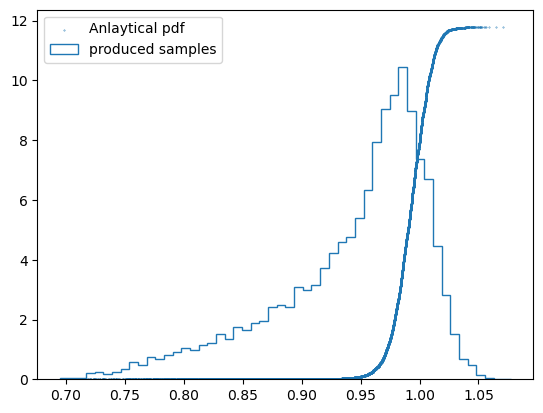

In [32]:
plt.scatter(np.sort(M_irr), np.sort(p_values), s= 0.1, label='Anlaytical pdf')
astropy.visualization.hist(M_irr,bins='freedman', histtype='step', label='produced samples', density = True)
plt.legend();

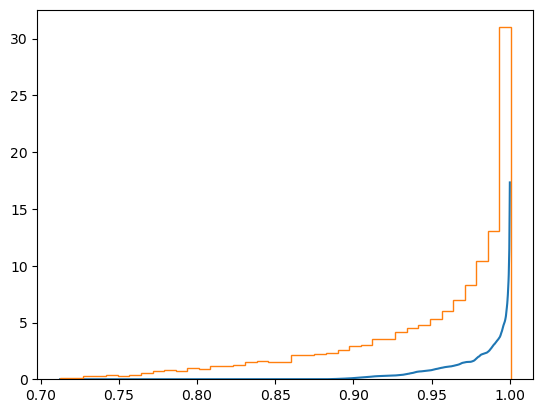

In [33]:
def kde_sklearn(data, bandwidth = 0.015, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

pdf_f = np.sort(kde_sklearn(f(y)))

plt.plot(np.sort(f(y)),pdf_f)
astropy.visualization.hist(f(y), bins= 'freedman', histtype='step', label='f(y)',density = True);
